In [1]:
import pandas as pd

ratings = pd.DataFrame({
    "restaurant": list("ABCDEFGHIJ"),
    "user_rating": [4.2, 4.0, 3.9, 4.5, 4.1, 1.0, 4.3, 4.4, 0.5, 4.2]
})

Q1 = ratings["user_rating"].quantile(0.25)
Q3 = ratings["user_rating"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = ratings[(ratings["user_rating"] < lower) | (ratings["user_rating"] > upper)]
print("Outlier indices:", outliers.index.tolist())
print(outliers)

Outlier indices: [5, 8]
  restaurant  user_rating
5          F          1.0
8          I          0.5


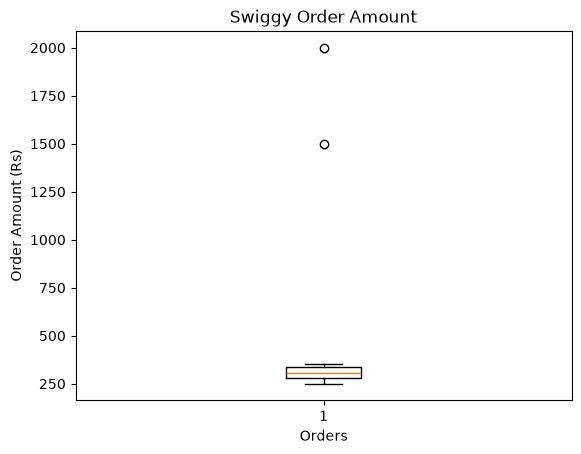

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.DataFrame({
    "order_amount": [250, 300, 280, 350, 320, 290, 310, 1500, 270, 330, 2000, 260]
})

plt.boxplot(orders["order_amount"])
plt.title("Swiggy Order Amount")
plt.xlabel("Orders")
plt.ylabel("Order Amount (Rs)")
plt.show()

In [3]:
import pandas as pd

paytm = pd.DataFrame({
    "transaction_amount": [100, 250, 300, 150, 400, 350, 200, 50000, 10, 500, 450, 275]
})

low = paytm["transaction_amount"].quantile(0.05)
high = paytm["transaction_amount"].quantile(0.95)

print("Before:")
print(paytm["transaction_amount"].describe())

paytm["transaction_amount"] = paytm["transaction_amount"].clip(lower=low, upper=high)

print("\nAfter winsorization:")
print(paytm["transaction_amount"].describe())

Before:
count       12.000000
mean      4415.416667
std      14356.135441
min         10.000000
25%        187.500000
50%        287.500000
75%        412.500000
max      50000.000000
Name: transaction_amount, dtype: float64

After winsorization:
count       12.000000
mean      2150.791667
std       6496.355151
min         59.500000
25%        187.500000
50%        287.500000
75%        412.500000
max      22775.000000
Name: transaction_amount, dtype: float64


In [4]:
import pandas as pd

prices = pd.DataFrame({
    "price": ["₹1,299", "₹24,999", "₹499", "₹8,750"]
})

prices["price"] = prices["price"].str.replace(r"[^\d.]", "", regex=True).astype(float)

print(prices)
print(prices.dtypes)

     price
0   1299.0
1  24999.0
2    499.0
3   8750.0
price    float64
dtype: object


In [5]:
import pandas as pd

spotify = pd.DataFrame({
    "is_premium": [True, "True", 1, "yes", "no", 0, False, "False", 2]
})

spotify["is_premium"] = spotify["is_premium"].apply(
    lambda x: str(x).strip().lower() in ["true", "1", "yes"]
)

print(spotify)
print(spotify.dtypes)

   is_premium
0        True
1        True
2        True
3        True
4       False
5       False
6       False
7       False
8       False
is_premium    bool
dtype: object
